In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [65]:
df = pd.read_csv('netflix_titles.csv')

In [66]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [67]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [69]:
df.describe().astype(int)

,release_year
count,8807
mean,2014
std,8
min,1925
25%,2013
50%,2017
75%,2019
max,2021


In [70]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100


In [71]:
missing_df = pd.DataFrame({'Missing_Values': missing,
                           "Percentage %": missing_pct.round(2)})
print(missing_df[missing_df['Missing_Values'] > 0])


            Missing_Values  Percentage %
director              2634         29.91
cast                   825          9.37
country                831          9.44
date_added              10          0.11
rating                   4          0.05
duration                 3          0.03


In [72]:
df[['director', 'cast', 'country', 'rating']] = df[['director', 'cast', 'country', 'rating']].fillna('Unknown')
df = df.dropna(subset=['date_added', 'duration'])

In [73]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [74]:
df['year_added'] = df['date_added'].dt.year
df['month_year'] = df['date_added'].dt.month_name()

In [75]:
print('Data Cleaned')
print(f'Remaning rows: , {df.shape[0]}')

Data Cleaned
Remaning rows: , 8794


In [76]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_year      0
dtype: int64

In [77]:
print('Content Type Count:')
print(df['type'].value_counts())
print()

Content Type Count:
type
Movie      6128
TV Show    2666
Name: count, dtype: int64



In [78]:
print('Percentage Split:')
print(df['type'].value_counts(normalize= True).mul(100).round(1).astype(str) + '%')

Percentage Split:
type
Movie      69.7%
TV Show    30.3%
Name: proportion, dtype: object


In [79]:
print('Top Countries:')

country_series = df['country'].str.split(',').explode().str.strip()
top_countries = country_series[country_series != 'Unknown'].value_counts().head(10)
print(top_countries)

Top Countries:
country
United States     3681
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [80]:
print('Top 10 Generes:')

genre_series = df['listed_in'].str.split(',').explode().str.strip()
top_genre = genre_series.value_counts().head(10)
print(top_genre)

Top 10 Generes:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [81]:
print('Content Added Per Year:')
yearly = df['year_added'].value_counts().sort_index()
print(yearly)

Content Added Per Year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


In [82]:
print('Top 10 Directors (excluding unknowns)')
director_series = df[df['director'] != 'Unknown']['director'].str.split(',').explode().str.strip()
top_directors = director_series.value_counts().head(10)
print(top_directors)

Top 10 Directors (excluding unknowns)
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Martin Scorsese        12
Youssef Chahine        12
Name: count, dtype: int64


In [83]:
print('Content Ratings:')
print(df['rating'].value_counts().head(10))

Content Ratings:
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


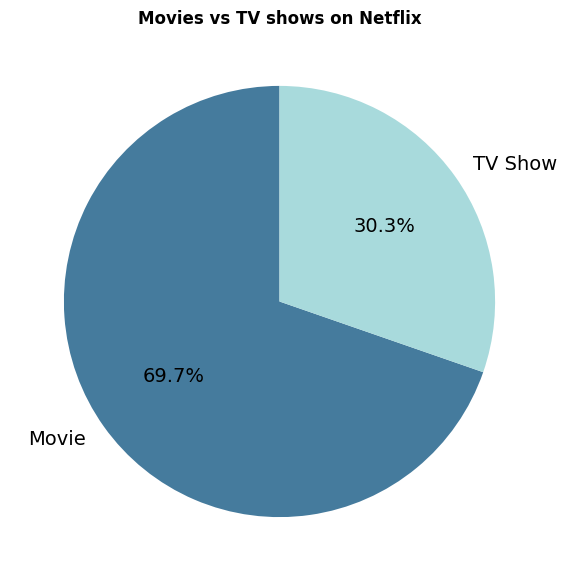

In [92]:
#Plot 1: Movies vs TV Shows (Pie Chart)

type_counts = df['type'].value_counts()

plt.figure(figsize= (7, 7))
plt.pie(type_counts, labels= type_counts.index, autopct='%1.1f%%',
        colors=["#457B9D", "#A8DADC"], 
        startangle=90, 
        textprops={'fontsize': 14})
plt.title('Movies vs TV shows on Netflix', fontsize= 12, fontweight= 'bold')
plt.show()

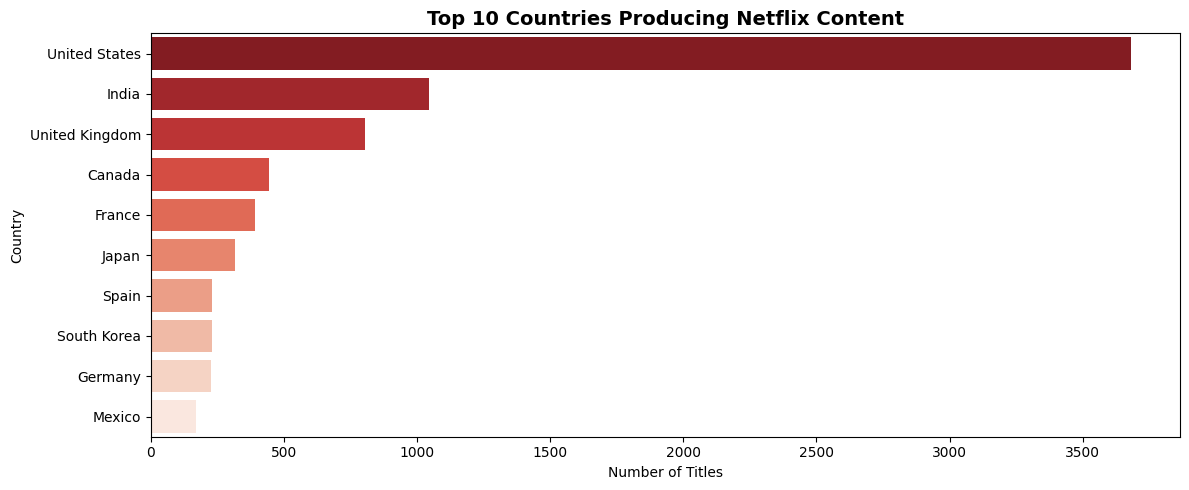

In [85]:
#Plot 2: Top 10 Countries (Bar Chart)

plt.figure(figsize= (12, 5))
sns.barplot(x=top_countries.values , y= top_countries.index, hue=top_genre.index, palette= 'Reds_r', legend= False)
plt.title('Top 10 Countries Producing Netflix Content', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

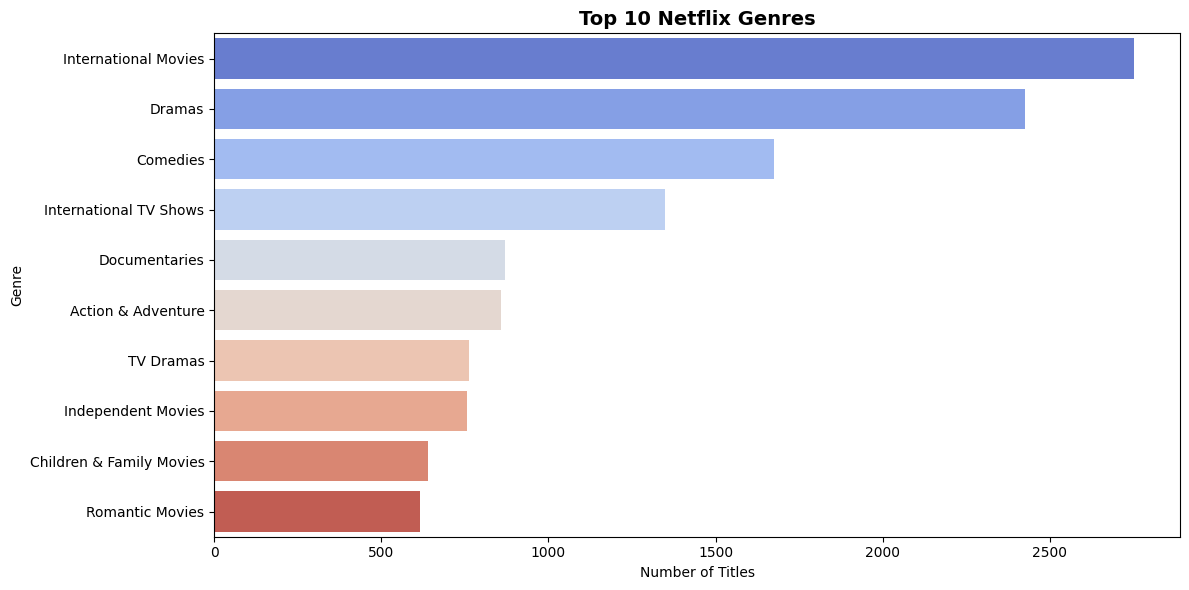

In [86]:
#Plot 3: Content Added Per Year (Line Chart)

plt.figure(figsize= (12, 6))
sns.barplot(x= top_genre.values, y= top_genre.index, hue=top_genre.index, palette= 'coolwarm', legend= False)
plt.title('Top 10 Netflix Genres', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

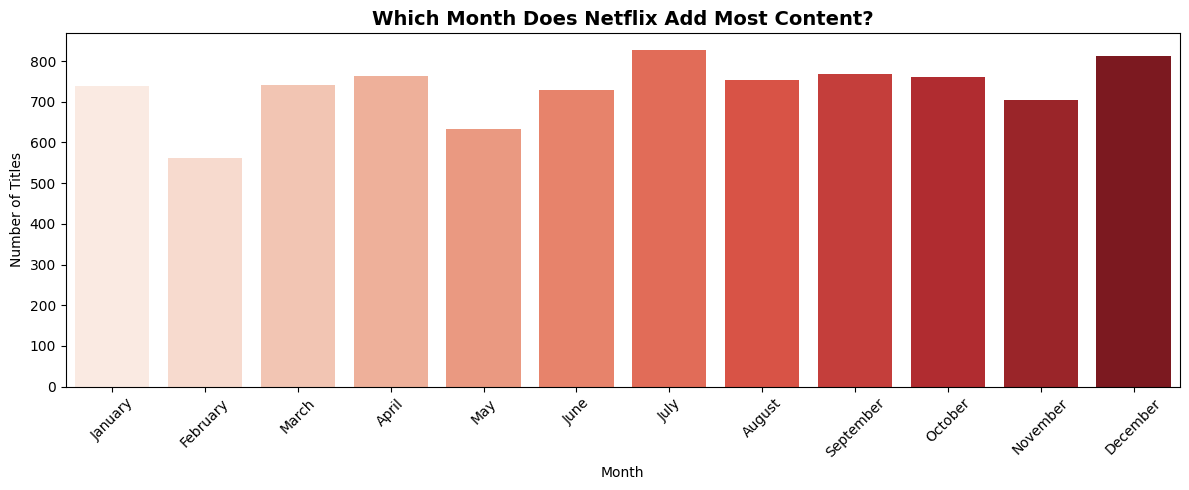

In [87]:
#Plot 5: Content Added Per Month (Bar Chart)

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df['month_year'].value_counts().reindex(month_order)

plt.figure(figsize= (12, 5))
sns.barplot(x=monthly.index, y=monthly.values, hue=monthly.index, palette='Reds', legend=False)
plt.title('Which Month Does Netflix Add Most Content?', fontsize=14, fontweight= 'bold')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

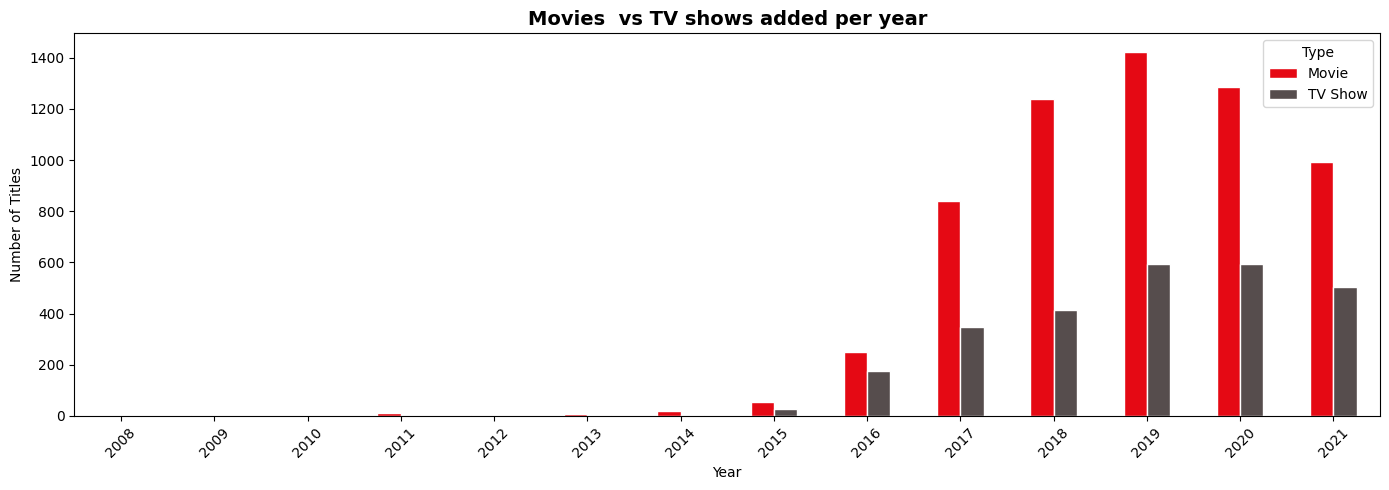

In [88]:
#Plot 6: Movies vs TV Shows added per year (Grouped Bar)

yearly_type = df.groupby(['year_added', 'type']).size().unstack().fillna(0)

yearly_type.plot(kind='bar', figsize=(14, 5), color=['#E50914', '#564d4d'], edgecolor='white')

plt.title('Movies  vs TV shows added per year', fontsize= 14, fontweight= 'bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation= 45)
plt.legend(title= 'Type')
plt.tight_layout()
plt.show()
